# 19 &middot; Compressed Vibration Modes: trading global modes for *local* ones

Classical **linear modal analysis (LMA)** describes how an elastic body likes to
vibrate. It diagonalizes the elastic energy against inertia &mdash; the generalized
eigenproblem

$$ H\,u \;=\; \omega^2\, M\,u , $$

with $H$ the (linear-elasticity) **stiffness** and $M$ the **mass** matrix. The
eigenvectors $u$ are the *mode shapes*. They are wonderful, but they share one
stubborn property: **every mode is global**. A low-frequency mode of a beam is a
sine wave that runs the entire length &mdash; touch one end and the whole shape
responds. That is exactly the wrong basis if you want to edit, actuate, or
simulate a body *part by part*.

**Compressed modes** fix this. Following *"Compressed Vibration Modes of Elastic
Bodies"* ([Brandt &amp; Hildebrandt,
2017](https://www.sciencedirect.com/science/article/abs/pii/S0167839617300377)),
we add an **$L_1$ penalty** to the modal energy. Each mode now solves

$$ \min_{u}\; \tfrac12\, u^\top H\, u \;+\; \lambda\,\lVert u\rVert_1
\qquad\text{s.t.}\quad u^\top M\,u = 1,\;\; u \perp_M \{\text{earlier modes}\}. $$

The quadratic term still rewards smooth, low-energy shapes; the $\lVert u\rVert_1$
term rewards shapes that are **exactly zero almost everywhere**. The single knob
$\lambda$ trades the two off. At $\lambda = 0$ we recover ordinary LMA (global
modes); as $\lambda$ grows, each mode shrinks its support and becomes a
**local**, **sparse** bump. `simkit.eigs_iccm` solves this problem &mdash; it
iteratively recasts each mode as a convex QP (splitting $u = u_+ - u_-$ to
linearize the $L_1$ term) and deflates against the modes already found.

In this tutorial we:
1. build a **free-standing** beam (pinned nowhere) and its $H$, $M$ operators,
2. compute the standard LMA modes and watch them oscillate &mdash; **global**,
3. crank $\lambda$ up and watch the same modes **localize**,
4. quantify the sparsity directly.

All modes are shown by **actuating them sinusoidally**, $x(t) = X + a\,\sin(2\pi
t)\,u$ &mdash; no simulation, just the mode shape breathing in and out.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
from IPython.display import display

import simkit
import utils
from simkit.eigs_iccm import eigs_iccm
from simkit.energies.linear_elasticity import linear_elasticity_hessian

os.makedirs("media", exist_ok=True)
np.random.seed(0)

## A free-standing beam

We mesh a long thin rectangle and **pin nothing** &mdash; the beam floats in
space. Two matrices drive everything:

* $H$, the **linear-elasticity stiffness** (the Hessian of small-strain elastic
  energy). It is constant and positive *semi*-definite. Because the beam is
  unconstrained, $H$ has a 3-dimensional null space: the two rigid translations
  and the in-plane rotation cost no energy.
* $M$, the **mass** matrix (lumped per-vertex mass, expanded to $x$/$y$ DOFs).

These are exactly the ingredients of both LMA and the compressed-mode problem.

beam: 240 vertices, 390 triangles, 480 DOFs


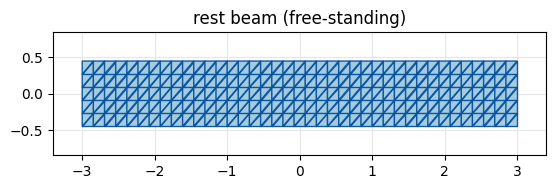

In [2]:
X, T = utils.triangulated_grid(40, 6, width=6.0, height=0.9)
n, dim = X.shape

mu = np.ones((T.shape[0], 1))                       # unit material; only the *shapes* matter
H  = linear_elasticity_hessian(X=X, T=T, mu=mu, lam=mu).tocsc()
M  = sps.kron(simkit.massmatrix(X, T), sps.identity(dim)).tocsc()

print(f"beam: {n} vertices, {T.shape[0]} triangles, {n*dim} DOFs")

fig, ax = plt.subplots(figsize=(7, 1.6))
utils.PolyMeshArtist(ax, X, T)
utils.setup_axes(ax, *utils.auto_limits([X]), title="rest beam (free-standing)")
plt.show()

## A tiny helper: actuate a mode sinusoidally

Every mode is a column $u \in \mathbb{R}^{n\cdot\text{dim}}$. To *see* it we
reshape it to a per-vertex displacement and sweep an amplitude through a full
sine period, $x(t) = X + a\,\sin(2\pi t)\,u$. We rescale each mode so its largest
vertex displacement is the same on screen &mdash; otherwise mass-normalized modes
would have wildly different visual amplitudes. `mode_panels` packages one beam
per mode for `utils.animate_meshes_grid`, which plays them in sync.

In [3]:
def mode_disp(col):
    "(n*dim,) modal column -> (n, dim) per-vertex displacement."
    return col.reshape(n, dim)

def mode_panels(B, titles, n_frames=36, target=0.32):
    "One animation panel per column of B: the beam actuated sinusoidally."
    phases = np.sin(2 * np.pi * np.arange(n_frames) / n_frames)
    panels = []
    for j in range(B.shape[1]):
        d   = mode_disp(B[:, j])
        amp = target / (np.linalg.norm(d, axis=1).max() + 1e-12)   # equal screen amplitude
        panels.append({"states": [X + (amp * p) * d for p in phases],
                       "T": T, "title": titles[j]})
    return panels

def active_fraction(B, thresh=0.05):
    "Fraction of (vertex, mode) pairs that actually move (> 5%% of that mode's peak)."
    mag = np.linalg.norm(B.reshape(n, dim, B.shape[1]), axis=1)
    return (mag > thresh * mag.max(axis=0)).mean()

mode_titles = [f"mode {i+1}" for i in range(5)]

## Standard linear modal analysis &mdash; global modes

`simkit.linear_modal_analysis` solves the plain generalized eigenproblem $Hu =
\omega^2 M u$ for the lowest modes. The first three come back with eigenvalue
$\approx 0$: those are the **rigid-body** modes (translate-$x$, translate-$y$,
rotate) that live in the null space of $H$. We drop them and keep the first five
genuine **deformation** modes.

Watch the animation: every mode is a standing wave that occupies the **whole
beam**. Mode $k$ simply adds another half-wavelength. This is the global
character we want to break.

eigenvalues (omega^2): [-0.      0.      0.      0.0668  0.403   0.7292  1.2043  2.5513]   <- first 3 are rigid-body modes
active-vertex fraction: 1.00  (nearly 1.0 - fully global)



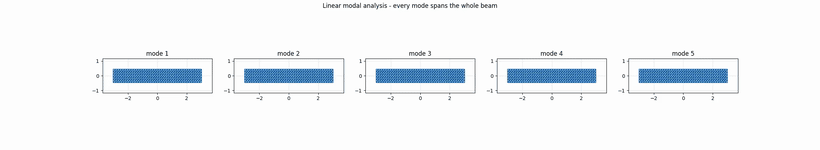

In [4]:
E, Blma = simkit.linear_modal_analysis(X, T, k=8)
print("eigenvalues (omega^2):", np.round(E, 4), "  <- first 3 are rigid-body modes")

Blma = Blma[:, 3:8]                                  # first 5 deformation modes
fig, anim = utils.animate_meshes_grid(
    mode_panels(Blma, mode_titles), fps=18,
    suptitle="Linear modal analysis - every mode spans the whole beam")
utils.save_anim(anim, "media/19_lma_modes.gif", fps=18)
plt.close(fig)
print(f"active-vertex fraction: {active_fraction(Blma):.2f}  (nearly 1.0 - fully global)")
display(utils.show_anim(anim, fps=18, width=820))

## Turning on the sparsity knob $\lambda$

Now we solve the **compressed**-mode problem with `eigs_iccm`, sweeping $\lambda$.
Read the animations top to bottom:

* **$\lambda = 0.5$** &mdash; light pressure. Modes still ripple over much of the
  beam, but the ends start going quiet.
* **$\lambda = 2$** &mdash; each mode now lives in a *region* of the beam; the rest
  is frozen.
* **$\lambda = 8$** &mdash; strong pressure. Modes collapse to compact, **local**
  bumps; only a small patch breathes while the remainder is rigid.

Same beam, same five modes &mdash; the only thing we changed is how much we charge
for *spreading out*.

In [5]:
lambdas = [0.5, 2.0, 8.0]
Bs = {}
for l in lambdas:
    np.random.seed(0)                                # deterministic random init per sweep
    Bs[l] = eigs_iccm(H, l=l, k=5, M=M, max_iters=25)
    print(f"lambda = {l:>4}:  active-vertex fraction {active_fraction(Bs[l]):.2f}")

lambda =  0.5:  active-vertex fraction 0.51


lambda =  2.0:  active-vertex fraction 0.31


lambda =  8.0:  active-vertex fraction 0.19



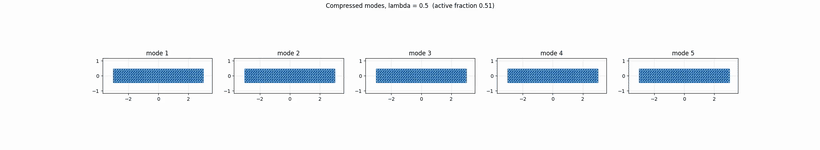

In [6]:
l = 0.5
fig, anim = utils.animate_meshes_grid(
    mode_panels(Bs[l], mode_titles), fps=18,
    suptitle=f"Compressed modes, lambda = {l}  (active fraction {active_fraction(Bs[l]):.2f})")
utils.save_anim(anim, f"media/19_iccm_l0.5.gif", fps=18)
plt.close(fig)
display(utils.show_anim(anim, fps=18, width=820))


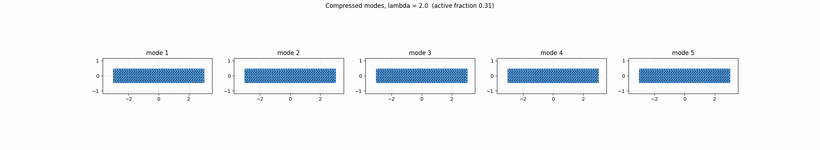

In [7]:
l = 2.0
fig, anim = utils.animate_meshes_grid(
    mode_panels(Bs[l], mode_titles), fps=18,
    suptitle=f"Compressed modes, lambda = {l}  (active fraction {active_fraction(Bs[l]):.2f})")
utils.save_anim(anim, f"media/19_iccm_l2.0.gif", fps=18)
plt.close(fig)
display(utils.show_anim(anim, fps=18, width=820))


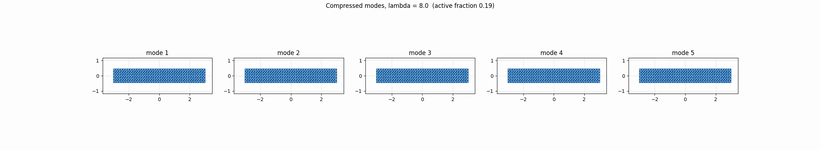

In [8]:
l = 8.0
fig, anim = utils.animate_meshes_grid(
    mode_panels(Bs[l], mode_titles), fps=18,
    suptitle=f"Compressed modes, lambda = {l}  (active fraction {active_fraction(Bs[l]):.2f})")
utils.save_anim(anim, f"media/19_iccm_l8.0.gif", fps=18)
plt.close(fig)
display(utils.show_anim(anim, fps=18, width=820))

## Seeing the support shrink directly

Animations show the *motion*; a heatmap of each mode's per-vertex displacement
magnitude on the **rest** beam shows the *support* at a glance. Bright = the
vertex participates in that mode, black = it stays put. Top row is LMA; each row
below raises $\lambda$. The bright region contracts monotonically &mdash; the
modes are literally becoming sparser.

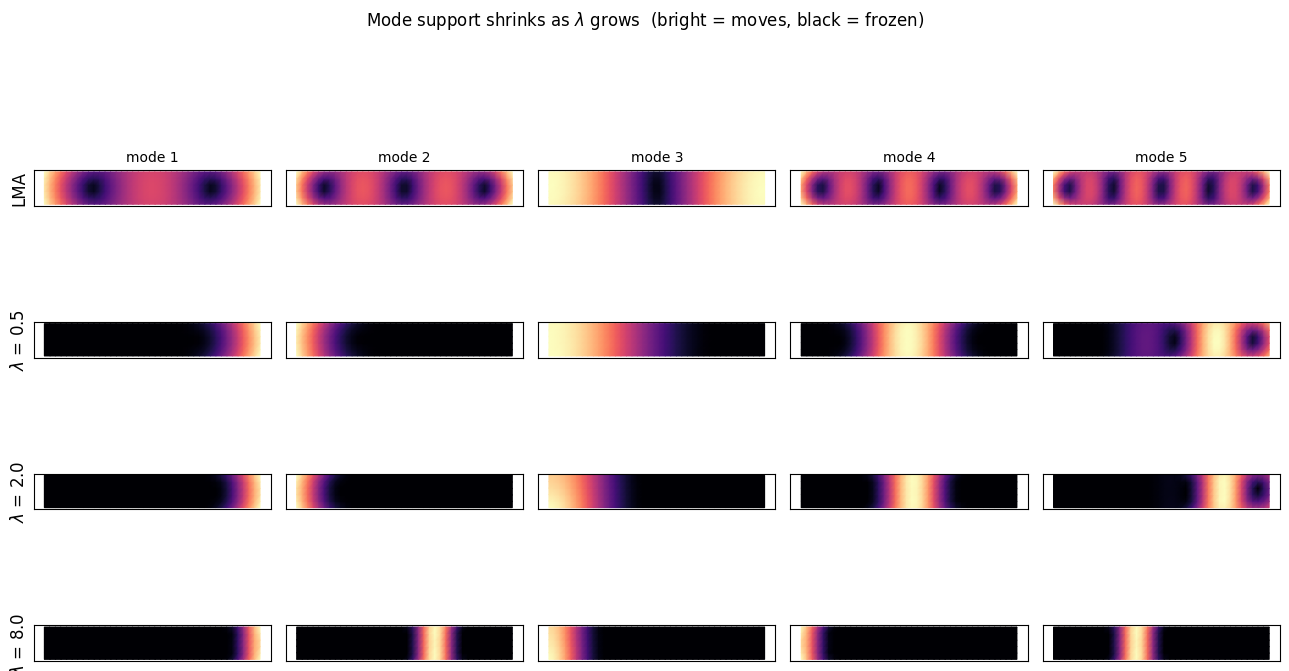

In [9]:
def heatmap_row(axes, B):
    for ax, j in zip(axes, range(B.shape[1])):
        mag = np.linalg.norm(mode_disp(B[:, j]), axis=1)
        ax.tripcolor(X[:, 0], X[:, 1], T, mag / (mag.max() + 1e-12),
                     shading="gouraud", cmap="magma", vmin=0, vmax=1)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

rows = [("LMA", Blma)] + [(f"$\\lambda$ = {l}", Bs[l]) for l in lambdas]
fig, axes = plt.subplots(len(rows), 5, figsize=(13, 1.9 * len(rows)))
for r, (name, B) in enumerate(rows):
    heatmap_row(axes[r], B)
    axes[r][0].set_ylabel(name, fontsize=12)
    if r == 0:
        for j in range(5):
            axes[0][j].set_title(f"mode {j+1}", fontsize=10)
fig.suptitle("Mode support shrinks as $\\lambda$ grows  (bright = moves, black = frozen)", y=1.01)
fig.tight_layout()
fig.savefig("media/19_heatmaps.png", dpi=110, bbox_inches="tight")
plt.show()

## Quantifying sparsity

The "active-vertex fraction" &mdash; the share of vertices whose displacement
exceeds 5% of a mode's peak, averaged over the five modes &mdash; falls off
steeply with $\lambda$. LMA modes touch essentially every vertex; by $\lambda =
8$ each mode lives on a small fraction of the beam.

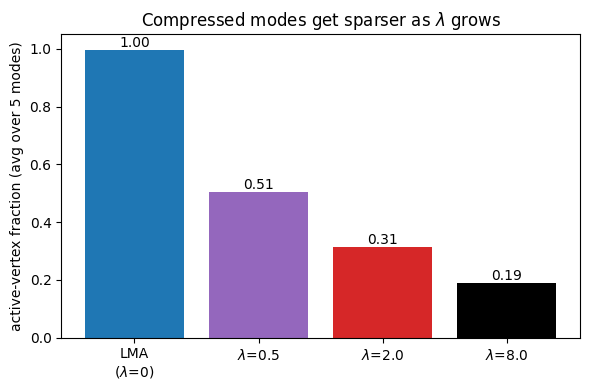

In [10]:
xs = ["LMA\n($\\lambda$=0)"] + [f"$\\lambda$={l}" for l in lambdas]
ys = [active_fraction(Blma)] + [active_fraction(Bs[l]) for l in lambdas]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(xs, ys, color=["#1f77b4", "#9467bd", "#d62728", "#000000"])
for i, v in enumerate(ys):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.05); ax.set_ylabel("active-vertex fraction (avg over 5 modes)")
ax.set_title("Compressed modes get sparser as $\\lambda$ grows")
fig.tight_layout(); fig.savefig("media/19_sparsity.png", dpi=110)
plt.show()

## Takeaways

* **LMA modes are global.** They diagonalize $H$ against $M$, and the
  low-frequency shapes inevitably span the whole body. Great for spectral
  analysis, awkward for local editing.
* **An $L_1$ penalty buys locality.** Minimizing $\tfrac12 u^\top H u + \lambda
  \lVert u\rVert_1$ (mass-normalized, deflated) keeps the modes smooth where they
  live but forces them to zero everywhere else.
* **One knob.** $\lambda$ slides continuously from global LMA ($\lambda\to 0$) to
  tightly localized bumps (large $\lambda$) &mdash; we watched both the motion and
  the support change with nothing else touched.
* **`simkit.eigs_iccm`** computes these compressed modes for any $(H, M)$ pair,
  so the same recipe applies to any mesh, not just this beam.

Localized modes are a natural basis for **part-based deformation**, **sparse
control / actuation**, and **domain-decomposed** reduced simulation &mdash; places
where a global modal basis would couple everything to everything.